# 📊 Análisis de Residuos Municipales Generados Anualmente — Perú (2014–2024)
**Fuente:** Ministerio del Ambiente (MINAM)  
**Dataset:** Residuos municipales generados anualmente  
**Autor:** Alexander Augusto Ramos Cuadros  

---

En este notebook se realizan **3 análisis exploratorios** sobre el dataset ya limpio y enriquecido con coordenadas geográficas:

1. 📈 **Evolución temporal** de residuos municipales por región natural (2014–2024)
2. 🏆 **Ranking de distritos** con mayor y menor generación per cápita (GPC_DOM)
3. 🗺️ **Mapa de calor geoespacial** de residuos municipales por distrito

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Configuración visual general para matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Cargamos el dataset trabajado
df = pd.read_excel("DataSet Residuos Municipales Trabajada.xlsx", dtype={"UBIGEO": str})

print(f"Registros totales : {len(df):,}")
print(f"Periodos          : {df['PERIODO'].min()} – {df['PERIODO'].max()}")
print(f"Distritos únicos  : {df['DISTRITO'].nunique():,}")
df.head(3)

Registros totales : 20,650
Periodos          : 2014 – 2024
Distritos únicos  : 1,733


,FECHA_CORTE,N_SEC,UBIGEO,REG_NAT,DEPARTAMENTO,PROVINCIA,DISTRITO,POB_TOTAL,POB_URBANA,POB_RURAL,GPC_DOM,QRESIDUOS_DOM,QRESIDUOS_NO_DOM,QRESIDUOS_MUN,PERIODO,latitud,longitud
0,2023-06-14,1,010101,SELVA,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,28423,27548,875,0.48,4857.50,2081.78,6939.28,2014,-6.2294,-77.8714
1,2023-06-14,2,010102,SELVA,AMAZONAS,CHACHAPOYAS,ASUNCION,291,151,140,0.61,33.56,14.38,47.95,2014,-6.0317,-77.7122
2,2023-06-14,3,010103,SIERRA,AMAZONAS,CHACHAPOYAS,BALSAS,1615,299,1316,0.45,48.96,20.98,69.95,2014,-6.8375,-78.0214


---
## 📈 Análisis 1 — Evolución temporal de residuos municipales por región natural (2014–2024)

**Objetivo:** Identificar cómo ha evolucionado la generación total de residuos municipales (Ton/Año) 
en cada región natural a lo largo de los años, y detectar tendencias o quiebres relevantes.

In [2]:
# Agrupamos por PERIODO y REG_NAT sumando los residuos municipales totales
df_evolucion = (
    df.groupby(["PERIODO", "REG_NAT"])["QRESIDUOS_MUN"]
    .sum()
    .reset_index()
)

# Calculamos variación porcentual año a año por región
df_evolucion = df_evolucion.sort_values(["REG_NAT", "PERIODO"])
df_evolucion["VAR_PCT"] = (
    df_evolucion.groupby("REG_NAT")["QRESIDUOS_MUN"]
    .pct_change() * 100
).round(2)

print("Residuos municipales totales (Ton/Año) por región y periodo:")
df_evolucion.pivot(index="PERIODO", columns="REG_NAT", values="QRESIDUOS_MUN").round(0)

Residuos municipales totales (Ton/Año) por región y periodo:


REG_NAT,COSTA,LIMA Y CALLAO,SELVA,SIERRA
PERIODO,,,,
2014,4796529.0,NaN,688134.0,1420288.0
2015,4942146.0,NaN,674777.0,1395875.0
2016,4933578.0,NaN,689951.0,1382047.0
2017,4984337.0,NaN,676805.0,1424503.0
2018,5168060.0,NaN,749024.0,1542498.0
2019,5455552.0,NaN,794463.0,1531889.0
2020,5564668.0,NaN,800905.0,1539545.0
2021,5786533.0,NaN,815092.0,1612731.0
2022,2128031.0,3852530.0,838141.0,1637013.0


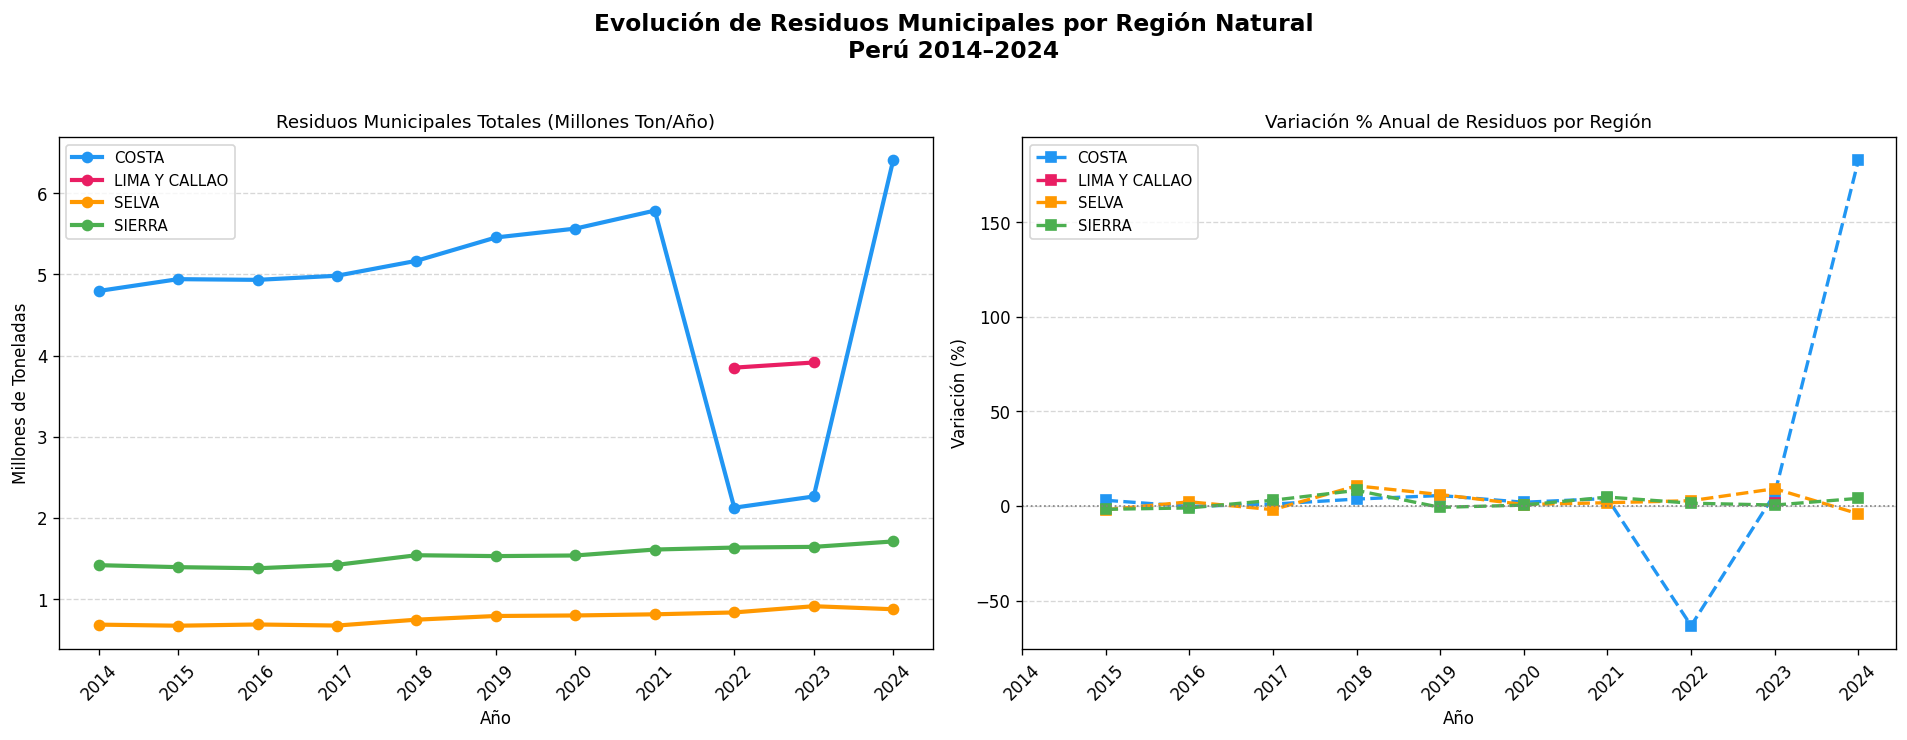

Gráfico guardado como evolucion_regional.png


In [3]:
# Paleta de colores por región
colores = {
    "COSTA"        : "#2196F3",
    "SIERRA"       : "#4CAF50",
    "SELVA"        : "#FF9800",
    "LIMA Y CALLAO": "#E91E63"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Evolución de Residuos Municipales por Región Natural\nPerú 2014–2024",
             fontsize=14, fontweight='bold', y=1.02)

# -- Gráfico 1: Líneas de evolución total --
ax1 = axes[0]
for region, grupo in df_evolucion.groupby("REG_NAT"):
    ax1.plot(
        grupo["PERIODO"], grupo["QRESIDUOS_MUN"] / 1_000_000,
        marker='o', linewidth=2.5, label=region, color=colores.get(region)
    )

ax1.set_title("Residuos Municipales Totales (Millones Ton/Año)", fontsize=11)
ax1.set_xlabel("Año")
ax1.set_ylabel("Millones de Toneladas")
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_xticks(df_evolucion["PERIODO"].unique())
ax1.tick_params(axis='x', rotation=45)

# -- Gráfico 2: Variación % año a año --
ax2 = axes[1]
for region, grupo in df_evolucion.groupby("REG_NAT"):
    grupo_sin_nan = grupo.dropna(subset=["VAR_PCT"])
    ax2.plot(
        grupo_sin_nan["PERIODO"], grupo_sin_nan["VAR_PCT"],
        marker='s', linewidth=2, linestyle='--', label=region, color=colores.get(region)
    )

ax2.axhline(0, color='gray', linewidth=1, linestyle=':')
ax2.set_title("Variación % Anual de Residuos por Región", fontsize=11)
ax2.set_xlabel("Año")
ax2.set_ylabel("Variación (%)")
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_xticks(df_evolucion["PERIODO"].unique())
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("evolucion_regional.png", bbox_inches='tight')
plt.show()
print("Gráfico guardado como evolucion_regional.png")

In [4]:
# Hallazgos clave del análisis 1
total_2014 = df[df['PERIODO'] == 2014]['QRESIDUOS_MUN'].sum()
total_2024 = df[df['PERIODO'] == 2024]['QRESIDUOS_MUN'].sum()
crecimiento = ((total_2024 - total_2014) / total_2014) * 100

region_mayor = (
    df[df['PERIODO'] == 2024]
    .groupby('REG_NAT')['QRESIDUOS_MUN'].sum()
    .idxmax()
)
pct_region_mayor = (
    df[df['PERIODO'] == 2024]
    .groupby('REG_NAT')['QRESIDUOS_MUN'].sum()
    .max() / total_2024 * 100
)

print("=" * 55)
print("  HALLAZGOS CLAVE — ANÁLISIS 1")
print("=" * 55)
print(f"  Total residuos 2014 : {total_2014:>15,.0f} Ton/Año")
print(f"  Total residuos 2024 : {total_2024:>15,.0f} Ton/Año")
print(f"  Crecimiento 10 años : {crecimiento:>14.1f}%")
print(f"  Región líder (2024) : {region_mayor} ({pct_region_mayor:.1f}% del total)")
print("=" * 55)

  HALLAZGOS CLAVE — ANÁLISIS 1
  Total residuos 2014 :       6,904,950 Ton/Año
  Total residuos 2024 :       8,994,763 Ton/Año
  Crecimiento 10 años :           30.3%
  Región líder (2024) : COSTA (71.2% del total)


---
## 🏆 Análisis 2 — Ranking de distritos por Generación Per Cápita (GPC_DOM)

**Objetivo:** Identificar los distritos con mayor y menor generación de residuos domiciliarios 
por habitante por día (Kg/Hab/Día), revelando desigualdades entre zonas urbanas y rurales.

> **GPC_DOM**: Kilogramos de residuos domiciliarios generados por persona por día.

In [5]:
# Promediamos GPC_DOM por distrito a lo largo de todos los años
# Excluimos valores 0 (datos faltantes codificados como 0)
df_gpc = (
    df[df['GPC_DOM'] > 0]
    .groupby(['UBIGEO', 'DISTRITO', 'DEPARTAMENTO', 'REG_NAT'])
    .agg(
        GPC_DOM_PROM   = ('GPC_DOM',      'mean'),
        POB_URBANA_PROM= ('POB_URBANA',   'mean'),
        AÑOS_REGISTRO  = ('PERIODO',      'nunique')
    )
    .reset_index()
    .round(3)
)

# Top 10 mayor GPC_DOM
top10_mayor = df_gpc.nlargest(10, 'GPC_DOM_PROM').reset_index(drop=True)
# Top 10 menor GPC_DOM
top10_menor = df_gpc.nsmallest(10, 'GPC_DOM_PROM').reset_index(drop=True)

print("TOP 10 — Mayor Generación Per Cápita (Kg/Hab/Día)")
print(top10_mayor[['DISTRITO','DEPARTAMENTO','REG_NAT','GPC_DOM_PROM','POB_URBANA_PROM']].to_string(index=False))

TOP 10 — Mayor Generación Per Cápita (Kg/Hab/Día)
                  DISTRITO DEPARTAMENTO       REG_NAT  GPC_DOM_PROM  POB_URBANA_PROM
                QUIRUVILCA  LA LIBERTAD        SIERRA         0.880         6945.545
                    NAMORA    CAJAMARCA        SIERRA         0.852         1687.000
                      LIMA         LIMA         COSTA         0.814       269303.111
                     LLAPO       ÁNCASH        SIERRA         0.800          590.000
                     MARCA       ÁNCASH        SIERRA         0.800         1895.000
                   OROPESA     APURÍMAC        SIERRA         0.800         1644.000
CARMEN DE LA LEGUA REYNOSO       CALLAO LIMA Y CALLAO         0.800        47199.000
                     PUÑOS      HUÁNUCO        SIERRA         0.800         1051.000
                  EL TAMBO        JUNÍN        SIERRA         0.800       168485.000
                 SAN RAMON        JUNÍN         SELVA         0.800        23852.000


In [6]:
print("TOP 10 — Menor Generación Per Cápita (Kg/Hab/Día)")
print(top10_menor[['DISTRITO','DEPARTAMENTO','REG_NAT','GPC_DOM_PROM','POB_URBANA_PROM']].to_string(index=False))

TOP 10 — Menor Generación Per Cápita (Kg/Hab/Día)
   DISTRITO DEPARTAMENTO REG_NAT  GPC_DOM_PROM  POB_URBANA_PROM
     TURPAY     APURÍMAC  SIERRA          0.13            547.0
     PAMPAS       ÁNCASH  SIERRA          0.20            294.0
    HUANTAR       ÁNCASH  SIERRA          0.20            901.0
      TAUCA       ÁNCASH  SIERRA          0.20           1223.0
   MATACOTO       ÁNCASH  SIERRA          0.20            321.0
KAQUIABAMBA     APURÍMAC  SIERRA          0.20            995.0
 COLCABAMBA     APURÍMAC  SIERRA          0.20            445.0
CANCHABAMBA      HUÁNUCO  SIERRA          0.20            469.0
     JIRCAN      HUÁNUCO   SELVA          0.20            219.0
HUACRACHUCO      HUÁNUCO  SIERRA          0.20           5496.0


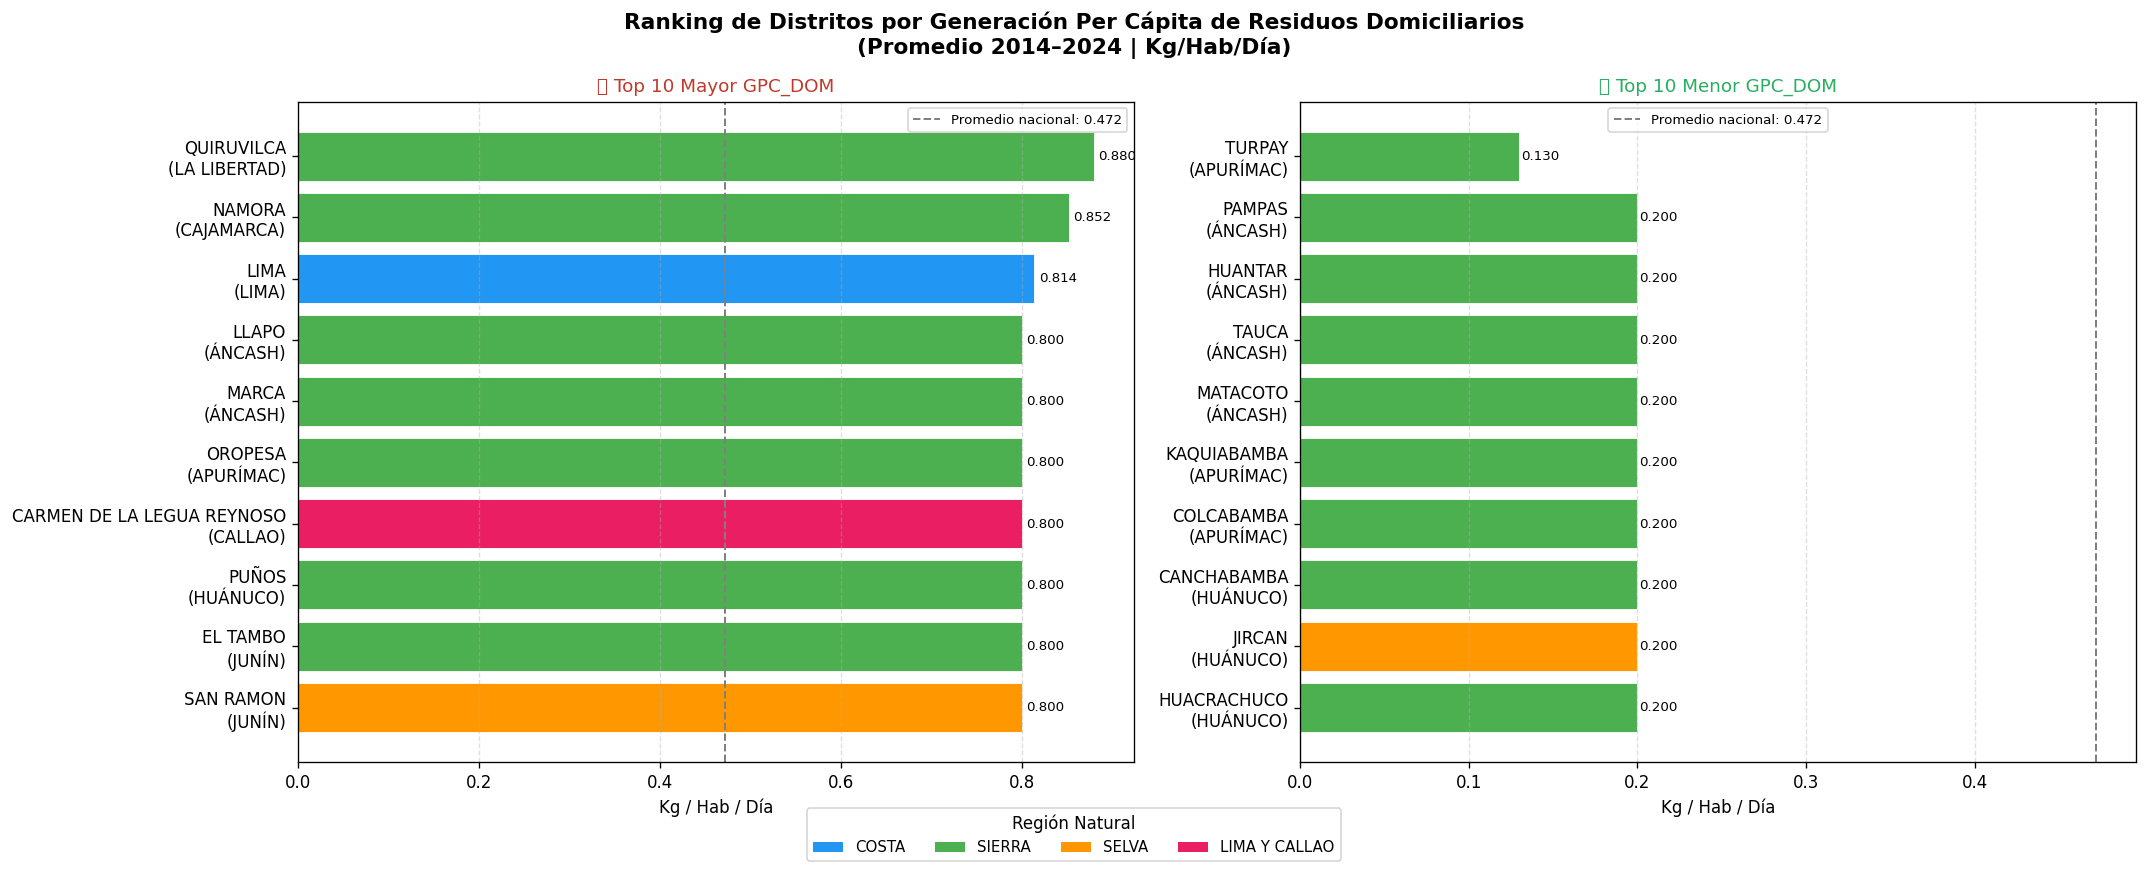

Gráfico guardado como ranking_gpc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Ranking de Distritos por Generación Per Cápita de Residuos Domiciliarios\n(Promedio 2014–2024 | Kg/Hab/Día)",
             fontsize=13, fontweight='bold')

# Mapa de color por región para las barras
def color_por_region(region):
    return colores.get(region, '#999999')

# -- Gráfico izquierdo: Top 10 MAYOR --
ax1 = axes[0]
labels_mayor = [
    f"{row.DISTRITO}\n({row.DEPARTAMENTO})"
    for _, row in top10_mayor.iterrows()
]
bar_colors_mayor = [color_por_region(r) for r in top10_mayor['REG_NAT']]
bars1 = ax1.barh(labels_mayor[::-1], top10_mayor['GPC_DOM_PROM'][::-1],
                 color=bar_colors_mayor[::-1], edgecolor='white', linewidth=0.5)
ax1.set_title("🔴 Top 10 Mayor GPC_DOM", fontsize=11, color='#C0392B')
ax1.set_xlabel("Kg / Hab / Día")
ax1.axvline(df_gpc['GPC_DOM_PROM'].mean(), color='gray', linestyle='--',
            linewidth=1.2, label=f"Promedio nacional: {df_gpc['GPC_DOM_PROM'].mean():.3f}")
ax1.legend(fontsize=8)
ax1.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars1, top10_mayor['GPC_DOM_PROM'][::-1]):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=8)

# -- Gráfico derecho: Top 10 MENOR --
ax2 = axes[1]
labels_menor = [
    f"{row.DISTRITO}\n({row.DEPARTAMENTO})"
    for _, row in top10_menor.iterrows()
]
bar_colors_menor = [color_por_region(r) for r in top10_menor['REG_NAT']]
bars2 = ax2.barh(labels_menor[::-1], top10_menor['GPC_DOM_PROM'][::-1],
                 color=bar_colors_menor[::-1], edgecolor='white', linewidth=0.5)
ax2.set_title("🟢 Top 10 Menor GPC_DOM", fontsize=11, color='#27AE60')
ax2.set_xlabel("Kg / Hab / Día")
ax2.axvline(df_gpc['GPC_DOM_PROM'].mean(), color='gray', linestyle='--',
            linewidth=1.2, label=f"Promedio nacional: {df_gpc['GPC_DOM_PROM'].mean():.3f}")
ax2.legend(fontsize=8)
ax2.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, top10_menor['GPC_DOM_PROM'][::-1]):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=8)

# Leyenda de colores de región
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, label=r) for r, c in colores.items()]
fig.legend(handles=leyenda, title='Región Natural', loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("ranking_gpc.png", bbox_inches='tight')
plt.show()
print("Gráfico guardado como ranking_gpc.png")

In [8]:
# Hallazgos clave del análisis 2
promedio_nacional = df_gpc['GPC_DOM_PROM'].mean()
max_row = df_gpc.loc[df_gpc['GPC_DOM_PROM'].idxmax()]
min_row = df_gpc.loc[df_gpc['GPC_DOM_PROM'].idxmin()]
brecha = max_row['GPC_DOM_PROM'] / min_row['GPC_DOM_PROM']

print("=" * 60)
print("  HALLAZGOS CLAVE — ANÁLISIS 2")
print("=" * 60)
print(f"  Promedio nacional GPC_DOM : {promedio_nacional:.3f} Kg/Hab/Día")
print(f"  Distrito mayor generación : {max_row['DISTRITO']} ({max_row['DEPARTAMENTO']}) — {max_row['GPC_DOM_PROM']:.3f}")
print(f"  Distrito menor generación : {min_row['DISTRITO']} ({min_row['DEPARTAMENTO']}) — {min_row['GPC_DOM_PROM']:.3f}")
print(f"  Brecha máx/mín            : {brecha:.1f}x")
print("=" * 60)

  HALLAZGOS CLAVE — ANÁLISIS 2
  Promedio nacional GPC_DOM : 0.472 Kg/Hab/Día
  Distrito mayor generación : QUIRUVILCA (LA LIBERTAD) — 0.880
  Distrito menor generación : TURPAY (APURÍMAC) — 0.130
  Brecha máx/mín            : 6.8x


---
## 🗺️ Análisis 3 — Mapa Geoespacial de Residuos Municipales por Distrito (2024)

**Objetivo:** Visualizar la distribución geográfica de la generación de residuos municipales 
en el territorio peruano usando las coordenadas de latitud/longitud enriquecidas previamente.

> Se utiliza el año **2024** (último disponible) para mostrar el estado más reciente.

In [9]:
# Filtramos el año más reciente con coordenadas válidas
df_mapa = df[
    (df['PERIODO'] == 2024) &
    (df['latitud'].notna()) &
    (df['longitud'].notna()) &
    (df['QRESIDUOS_MUN'] > 0)
].copy()

# Texto tooltip para el mapa
df_mapa['INFO'] = (
    df_mapa['DISTRITO'] + ' — ' + df_mapa['DEPARTAMENTO'] +
    '<br>Región: ' + df_mapa['REG_NAT'] +
    '<br>Residuos: ' + df_mapa['QRESIDUOS_MUN'].round(0).astype(int).apply(lambda x: f'{x:,}') + ' Ton/Año' +
    '<br>GPC_DOM: ' + df_mapa['GPC_DOM'].astype(str) + ' Kg/Hab/Día' +
    '<br>Pob. Urbana: ' + df_mapa['POB_URBANA'].apply(lambda x: f'{x:,}')
)

print(f"Distritos en el mapa : {len(df_mapa):,}")
print(f"Total residuos 2024  : {df_mapa['QRESIDUOS_MUN'].sum():,.0f} Ton/Año")
df_mapa[['DISTRITO','DEPARTAMENTO','REG_NAT','QRESIDUOS_MUN','latitud','longitud']].head()

Distritos en el mapa : 1,891
Total residuos 2024  : 8,994,763 Ton/Año


,DISTRITO,DEPARTAMENTO,REG_NAT,QRESIDUOS_MUN,latitud,longitud
18759,CHACHAPOYAS,AMAZONAS,SELVA,10521.91,-6.2294,-77.8714
18760,ASUNCION,AMAZONAS,SELVA,35.93,-6.0317,-77.7122
18761,BALSAS,AMAZONAS,SIERRA,64.76,-6.8375,-78.0214
18762,CHETO,AMAZONAS,SIERRA,105.12,-6.2558,-77.7003
18763,CHILIQUIN,AMAZONAS,SIERRA,33.79,-6.0778,-77.7392


In [10]:
fig_mapa = px.scatter_geo(
    df_mapa,
    lat             = 'latitud',
    lon             = 'longitud',
    size            = 'QRESIDUOS_MUN',
    color           = 'REG_NAT',
    hover_name      = 'DISTRITO',
    hover_data      = {
        'DEPARTAMENTO'  : True,
        'QRESIDUOS_MUN' : ':,.0f',
        'GPC_DOM'       : True,
        'POB_URBANA'    : ':,',
        'latitud'       : False,
        'longitud'      : False,
        'REG_NAT'       : False
    },
    color_discrete_map = {
        'COSTA'        : '#2196F3',
        'SIERRA'       : '#4CAF50',
        'SELVA'        : '#FF9800',
        'LIMA Y CALLAO': '#E91E63'
    },
    size_max        = 40,
    scope           = 'south america',
    title           = '🗺️ Residuos Municipales por Distrito — Perú 2024 (Ton/Año)',
    labels          = {
        'REG_NAT'       : 'Región Natural',
        'QRESIDUOS_MUN' : 'Residuos Mun. (Ton/Año)',
        'GPC_DOM'       : 'GPC Domiciliaria (Kg/Hab/Día)',
        'POB_URBANA'    : 'Población Urbana',
        'DEPARTAMENTO'  : 'Departamento'
    }
)

fig_mapa.update_geos(
    center          = dict(lat=-9.19, lon=-75.0),
    projection_scale= 4,
    showland        = True,
    landcolor       = '#F5F5F0',
    showocean       = True,
    oceancolor      = '#D6EAF8',
    showlakes       = True,
    lakecolor       = '#AED6F1',
    showcountries   = True,
    countrycolor    = '#BDBDBD'
)

fig_mapa.update_layout(
    height          = 700,
    legend_title    = 'Región Natural',
    font            = dict(family='Arial', size=12),
    title_font_size = 15
)

fig_mapa.show()
fig_mapa.write_html("mapa_residuos_2024.html")
print("Mapa interactivo guardado como mapa_residuos_2024.html")

Mapa interactivo guardado como mapa_residuos_2024.html


In [11]:
# Análisis complementario: Top 5 distritos por residuos en 2024
top5_2024 = (
    df_mapa
    .nlargest(5, 'QRESIDUOS_MUN')
    [['DISTRITO', 'DEPARTAMENTO', 'REG_NAT', 'QRESIDUOS_MUN', 'POB_URBANA', 'GPC_DOM']]
    .reset_index(drop=True)
)
top5_2024.index += 1

pct_top5 = top5_2024['QRESIDUOS_MUN'].sum() / df_mapa['QRESIDUOS_MUN'].sum() * 100

print("=" * 65)
print("  HALLAZGOS CLAVE — ANÁLISIS 3")
print("=" * 65)
print(f"  Total distritos mapeados : {len(df_mapa):,}")
print(f"  Top 5 concentran         : {pct_top5:.1f}% del total nacional")
print()
print("  Top 5 distritos por residuos municipales (2024):")
print(top5_2024.to_string())
print("=" * 65)

  HALLAZGOS CLAVE — ANÁLISIS 3
  Total distritos mapeados : 1,891
  Top 5 concentran         : 15.2% del total nacional

  Top 5 distritos por residuos municipales (2024):
                 DISTRITO DEPARTAMENTO REG_NAT  QRESIDUOS_MUN  POB_URBANA  GPC_DOM
1  SAN JUAN DE LURIGANCHO         LIMA   COSTA      408652.54     1264060     0.62
2    SAN MARTIN DE PORRES         LIMA   COSTA      268605.64      792514     0.65
3                     ATE         LIMA   COSTA      258927.91      730256     0.68
4                   COMAS         LIMA   COSTA      248694.73      596186     0.80
5              CARABAYLLO         LIMA   COSTA      183822.34      440670     0.80


---
## 📌 Conclusiones Generales

1. **Crecimiento sostenido:** La generación de residuos municipales creció consistentemente entre 2014 y 2024 en todas las regiones naturales del Perú, impulsada principalmente por el crecimiento de la población urbana.

2. **Concentración en Lima y Callao:** La región Lima y Callao concentra la mayor parte de los residuos generados a nivel nacional, aunque también presenta una GPC_DOM elevada en comparación con regiones como la Selva.

3. **Desigualdad per cápita:** Existe una brecha significativa en la generación per cápita (GPC_DOM) entre distritos. Los distritos más urbanizados y con mayor actividad económica tienden a generar considerablemente más residuos por habitante que los distritos rurales.

4. **Distribución geográfica:** El mapa revela que los focos de mayor generación de residuos coinciden con las capitales departamentales y zonas costeras, mientras que la Selva y Sierra muestran menores volúmenes absolutos pero con importantes dispersiones geográficas.

---
*Proyecto parte del portafolio de ingenería y análisis de datos de Alexander Augusto Ramos Cuadros*  
*GitHub: https://github.com/MixedCuy | LinkedIn: https://www.linkedin.com/in/alexander-ramos-9374a214a *